Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_20/rho_0.710/kT_0.800/nsteps_1000000/seed_1/randomization.gsd
Created new cavitation initial state
state_path: /exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_20/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_fraction_0.200/center_box/cavitation_initial.gsd
creation_metadata_path: /exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_20/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_fraction_0.200/center_box/cavitation_creation.hdf5
radius_fraction: 0.2
bubble_radius: 3.5587478637695313
bubble_center: [0. 0. 0.]
particles_removed: 141
N_before: 32000
N_after: 31859
rho_before: 0.7099999529577021
rho_after: 0.7068715156649822
Using GPU device
Final device: <hoomd.device.GPU object at 0x7f9f24220e20>
Started HDF5 logger
Log file: /exp/e961/data/MDsims-d

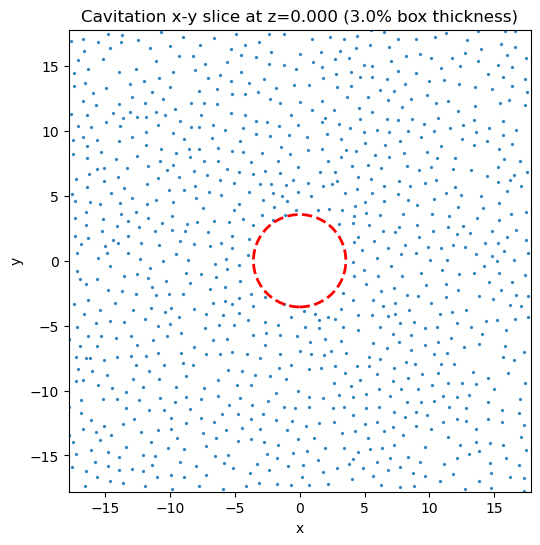

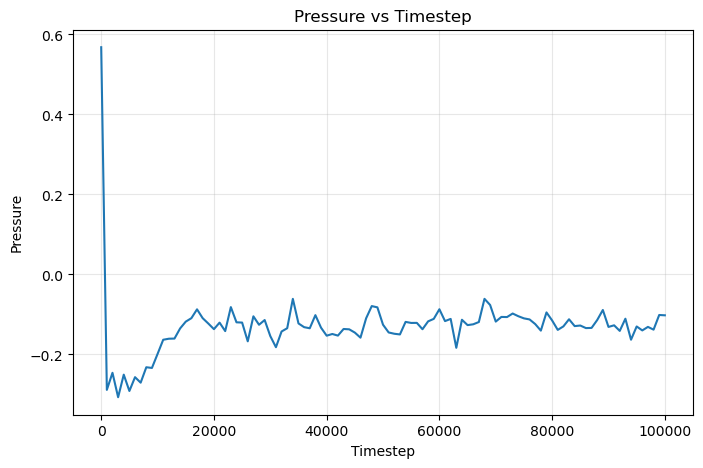

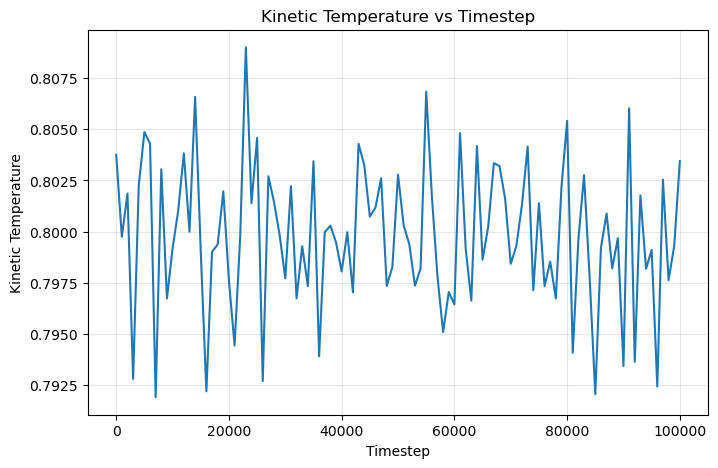

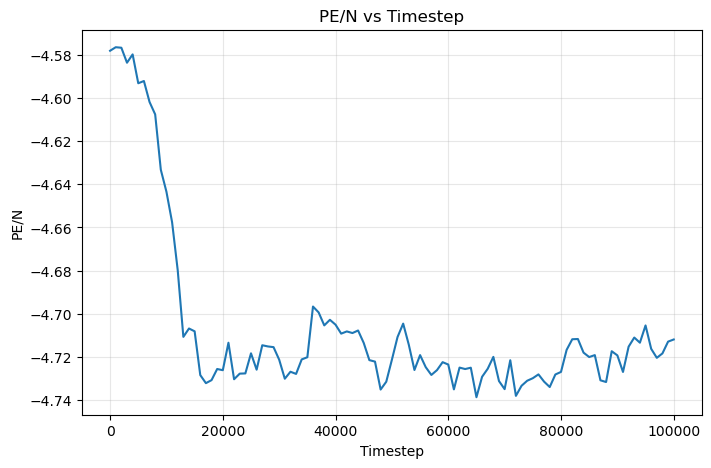

In [15]:
import importlib
from md_Helpers import visualization as vh
importlib.reload(vh)

import importlib
from md_Helpers import cavitation as cav
from md_Helpers import runs

importlib.reload(runs)
importlib.reload(cav)

evolution = cav.get_or_create_cavitation(
    n_fcc_cells=20,
    target_rho=0.71,
    kT=0.80,
    source_nsteps=1_000_000,
    radius_fraction=0.2,
    evolve_nsteps=100_000,

    create_source_if_missing=True,
    overwrite_source=False,
    overwrite=False,
)

print("Evolution status:", evolution["status"])
print("Source status:", evolution["initial_result"]["source_result"]["status"])

vh.plot_cavitation_xy_slice(
    evolution["initial_result"],
    fraction=0.03,
    point_size=2,
    alpha=0.8,
    show_bubble=True,
)

log_path = evolution["paths"]["log_path"]
log = runs.read_hdf5_log(log_path)

vh.plot_log_quantity(log, "pressure")
vh.plot_log_quantity(log, "kinetic_temperature")
vh.plot_log_quantity(log, "potential_energy")

In [17]:
from md_Helpers import visualization as vh

trajectory_path = evolution["paths"]["trajectory_path"]
center_z = evolution["initial_result"]["creation_info"].get("bubble_center_z", 0.0)

vh.animate_xy_slice_trajectory(
    trajectory_path,
    fraction=0.03,
    max_frames=100,
    interval=120,
)

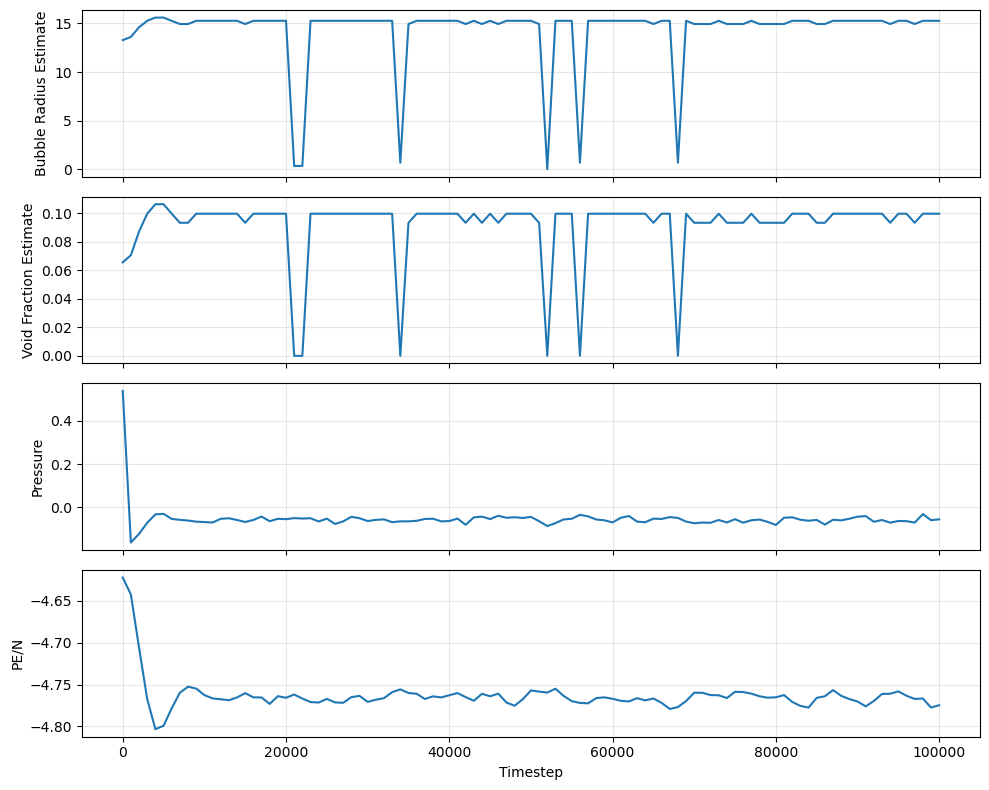

In [94]:
import importlib
from md_Helpers import cavitation as cav
from md_Helpers import visualization as vh

importlib.reload(cav)
importlib.reload(vh)

measurements = cav.measure_cavitation_trajectory(
    evolution,
    n_radial_bins=80,
    density_threshold_fraction=0.5,
    save_csv_path=evolution["paths"]["folder"] / "cavitation_measurements.csv",
)
vh.plot_cavitation_measurements(measurements)

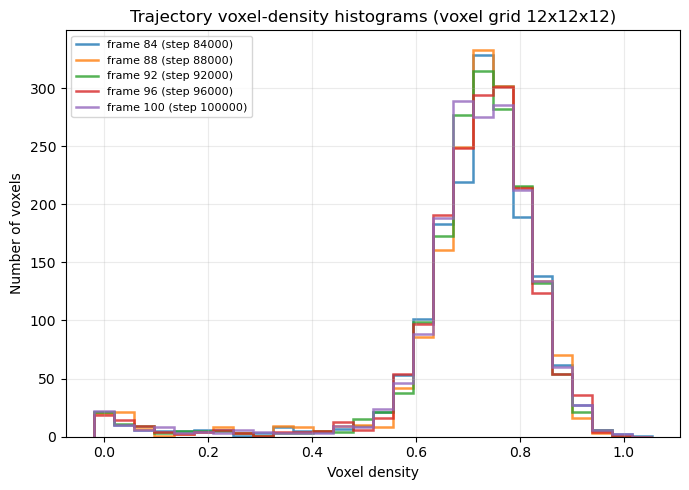

[{'frame_index': 84,
  'timestep': 84000,
  'mean_density': 0.7068715156649821,
  'std_density': 0.15107611882589703,
  'min_density': 0.0,
  'max_density': 1.0351799314123293,
  'empty_voxels': 21},
 {'frame_index': 88,
  'timestep': 88000,
  'mean_density': 0.7068715156649821,
  'std_density': 0.15478288150754088,
  'min_density': 0.0,
  'max_density': 0.9968399339526135,
  'empty_voxels': 20},
 {'frame_index': 92,
  'timestep': 92000,
  'mean_density': 0.7068715156649819,
  'std_density': 0.14890266684856357,
  'min_density': 0.0,
  'max_density': 0.9968399339526135,
  'empty_voxels': 21},
 {'frame_index': 96,
  'timestep': 96000,
  'mean_density': 0.7068715156649819,
  'std_density': 0.15032493072781825,
  'min_density': 0.0,
  'max_density': 0.9968399339526135,
  'empty_voxels': 19},
 {'frame_index': 100,
  'timestep': 100000,
  'mean_density': 0.7068715156649821,
  'std_density': 0.15061342317828116,
  'min_density': 0.0,
  'max_density': 0.9968399339526135,
  'empty_voxels': 22}

In [19]:
import importlib
from md_Helpers import visualization as vh

importlib.reload(vh)

voxel_hist = vh.plot_trajectory_voxel_histograms(
    evolution,
    nbins=12,
    last_n=5,
    skip=4,
    histogram_bins="shared_counts",
    normalize=False,
)

voxel_hist["selected_frame_indices"]
voxel_hist["summary"]

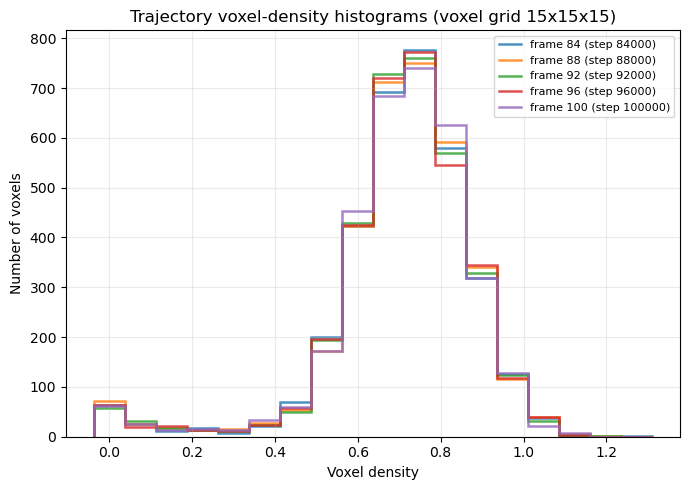

{'trajectory_path': '/exp/e961/data/MDsims-data/pnichols/Cavitation_Evolved_v3/FCC/n_cells_20/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_fraction_0.200/center_box/evolve_kT_0.800/nsteps_100000/seed_1/cavitation_trajectory.gsd',
 'selected_frame_indices': [84, 88, 92, 96, 100],
 'summary': [{'frame_index': 84,
   'timestep': 84000,
   'mean_density': 0.7068715156649819,
   'std_density': 0.17682519442496403,
   'min_density': 0.0,
   'max_density': 1.2730077281546295,
   'empty_voxels': 64},
  {'frame_index': 88,
   'timestep': 88000,
   'mean_density': 0.7068715156649819,
   'std_density': 0.18126218026279145,
   'min_density': 0.0,
   'max_density': 1.1981249206161217,
   'empty_voxels': 71},
  {'frame_index': 92,
   'timestep': 92000,
   'mean_density': 0.7068715156649819,
   'std_density': 0.17598670819775383,
   'min_density': 0.0,
   'max_density': 1.1981249206161217,
   'empty_voxels': 58},
  {'frame_index': 96,
   'timestep': 

In [20]:
vh.plot_trajectory_voxel_histograms(
    evolution,
    nbins=15,
    last_n=5,
    skip=4,
)

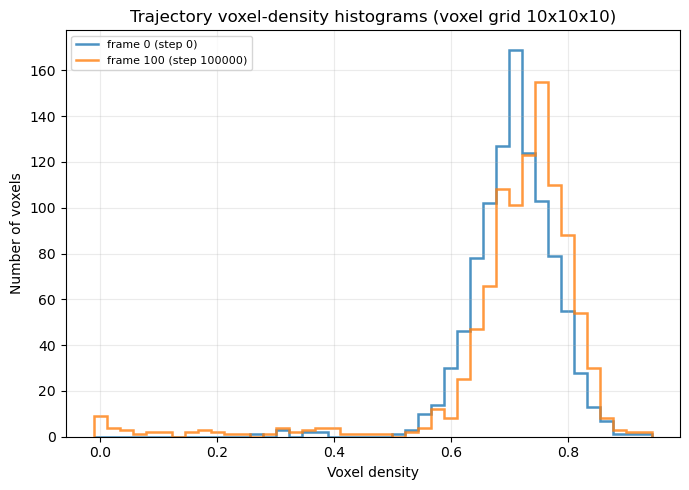

{'trajectory_path': '/exp/e961/data/MDsims-data/pnichols/Cavitation_Evolved_v3/FCC/n_cells_20/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_fraction_0.200/center_box/evolve_kT_0.800/nsteps_100000/seed_1/cavitation_trajectory.gsd',
 'selected_frame_indices': [0, 100],
 'summary': [{'frame_index': 0,
   'timestep': 0,
   'mean_density': 0.7068715156649821,
   'std_density': 0.07085186511936216,
   'min_density': 0.26624998235913827,
   'max_density': 0.9318749382569839,
   'empty_voxels': 0},
  {'frame_index': 100,
   'timestep': 100000,
   'mean_density': 0.7068715156649821,
   'std_density': 0.13766196694895685,
   'min_density': 0.0,
   'max_density': 0.9318749382569839,
   'empty_voxels': 9}],
 'density_edges': array([-0.01109375,  0.01109375,  0.03328125,  0.05546875,  0.07765624,
         0.09984374,  0.12203124,  0.14421874,  0.16640624,  0.18859374,
         0.21078124,  0.23296873,  0.25515623,  0.27734373,  0.29953123,
         

In [22]:
vh.plot_trajectory_voxel_histograms(
    evolution,
    nbins=10,
    frame_indices=[0,-1],
)